<a href="https://colab.research.google.com/github/jpnoug/spectropy/blob/main/Analyse_du_spectre_de_NGC4565.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyse du spectre de NGC 4565 (Alpy 600 Newton 200, 6 x 600 sec)

Analyse et rendu du spectre 1D de la galaxie **NGC 4565** (galaxie spirale vue par la tranche, dans la Chevelure de Bérénice), obtenu avec le spectrographe **Alpy 600** sur le **Newton 200 mm** (fente 23 µm, caméra Atik 414EX), réduit sous ISIS.

Ce notebook produit d'abord un graphe **intensité vs longueur d'onde** avec un rendu de couleur physique **λ → RGB** et annote les raies typiques d'une galaxie (CaII H&K, bande G, Hβ, Mg b, Na D, Hα, série de Balmer) ainsi que la rupture à 4000 Å (**D4000 / Ca break**).

Puis le notebook analyse le spectre : Ca break, EW de raies, couleur/température intégrée, Hα absorption vs émission, vitesse par centroïdes avec budgets d'erreur séparés, CCF multi-templates vs étoiles K Pickles, correction héliocentrique, et contrôle indépendant de calibration en longueur d'onde du spectro avec l'étoile de référence Melchiors.


# Analyse du spectre de NGC 4565 (Alpy 600 Newton 200, 6 x 600 sec)

Analyse et rendu du spectre 1D de la galaxie **NGC 4565** (galaxie spirale vue par la tranche, dans la Chevelure de Bérénice), obtenu avec le spectrographe **Alpy 600** sur le **Newton 200 mm** (fente 23 µm, caméra Atik 414EX), réduit sous ISIS.

Ce notebook produit d'abord un graphe **intensité vs longueur d'onde** avec un rendu de couleur physique **λ → RGB** et annote les raies typiques d'une galaxie (CaII H&K, bande G, Hβ, Mg b, Na D, Hα, série de Balmer) ainsi que la rupture à 4000 Å (**D4000 / Ca break**).

Puis le notebook analyse le spectre : Ca break, EW de raies, couleur/température intégrée, Hα absorption vs émission, vitesse par centroïdes avec budgets d'erreur séparés, CCF multi-templates vs étoiles K Pickles, correction héliocentrique, et contrôle indépendant de calibration en longueur d'onde du spectro avec l'étoile de référence Melchiors.


# Analyse du spectre de NGC 4565 (Alpy 600 Newton 200, 6 x 600 sec)

Analyse et rendu du spectre 1D de la galaxie **NGC 4565** (galaxie spirale vue par la tranche, dans la Chevelure de Bérénice), obtenu avec le spectrographe **Alpy 600** sur le **Newton 200 mm** (fente 23 µm, caméra Atik 414EX), réduit sous ISIS.

Ce notebook produit d'abord un graphe **intensité vs longueur d'onde** avec un rendu de couleur physique **λ → RGB** et annote les raies typiques d'une galaxie (CaII H&K, bande G, Hβ, Mg b, Na D, Hα, série de Balmer) ainsi que la rupture à 4000 Å (**D4000 / Ca break**).

Puis le notebook analyse le spectre : Ca break, EW de raies, couleur/température intégrée, Hα absorption vs émission, vitesse par centroïdes avec budgets d'erreur séparés, CCF multi-templates vs étoiles K Pickles, correction héliocentrique, et contrôle indépendant de calibration en longueur d'onde du spectro avec l'étoile de référence Melchiors.


# Analyse du spectre de NGC 4565 (Alpy 600 Newton 200, 6 x 600 sec)

Analyse et rendu du spectre 1D de la galaxie **NGC 4565** (galaxie spirale vue par la tranche, dans la Chevelure de Bérénice), obtenu avec le spectrographe **Alpy 600** sur le **Newton 200 mm** (fente 23 µm, caméra Atik 414EX), réduit sous ISIS.

Ce notebook produit d'abord un graphe **intensité vs longueur d'onde** avec un rendu de couleur physique **λ → RGB** et annote les raies typiques d'une galaxie (CaII H&K, bande G, Hβ, Mg b, Na D, Hα, série de Balmer) ainsi que la rupture à 4000 Å (**D4000 / Ca break**).

Puis le notebook analyse le spectre : Ca break, EW de raies, couleur/température intégrée, Hα absorption vs émission, vitesse par centroïdes avec budgets d'erreur séparés, CCF multi-templates vs étoiles K Pickles, correction héliocentrique, et contrôle indépendant de calibration en longueur d'onde du spectro avec l'étoile de référence Melchiors.


## 1. Dépendances et upload du FITS

In [21]:
# Sur Colab, les paquets sont déjà présents pour l'essentiel.
# Décommenter si besoin :
# !pip install astropy -q


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from astropy.io import fits

# --- Récupération du fichier FITS ---
# Option A (Colab) : upload manuel
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

FITS_PATH = "_ngc4565_20260615_870.fits"  # adapter le chemin si local (VSCode)

import os
if IN_COLAB and not os.path.exists(FITS_PATH):
    uploaded = files.upload()
    FITS_PATH = list(uploaded.keys())[0]

print("Fichier :", FITS_PATH)


Fichier : _ngc4565_20260615_870.fits


## 2. Lecture du spectre et construction de l'axe en longueur d'onde

In [23]:
hdu = fits.open(FITS_PATH)[0]
hdr = hdu.header
flux = hdu.data.astype(float)

n     = hdr["NAXIS1"]
crval = hdr["CRVAL1"]
cdelt = hdr["CDELT1"]
crpix = hdr.get("CRPIX1", 1)

# Axe en longueur d'onde (Angstrom), convention CRPIX1 (pixel de référence, base 1)
wl = crval + (np.arange(n) - (crpix - 1)) * cdelt

print(f"Objet      : {hdr.get('OBJNAME','?')}")
print(f"Date-obs   : {hdr.get('DATE-OBS','?')}")
print(f"Instrument : {hdr.get('BSS_INST','?')}")
print(f"Expo       : {hdr.get('EXPTIME','?')} s  ({hdr.get('EXPTIME2','')})")
print(f"R (pouvoir): {hdr.get('SPE_RPOW','?')}")
print(f"Domaine    : {wl[0]:.1f} – {wl[-1]:.1f} Å  ({n} points, {cdelt:.3f} Å/px)")
print(f"Flux       : min={np.nanmin(flux):.3f}  med={np.nanmedian(flux):.3f}  max={np.nanmax(flux):.3f}")


Objet      : NGC4565
Date-obs   : 2026-06-15T20:53:22
Instrument : Newt 200 Alpy 600 fente 23?m hp Atik414
Expo       : 3611 s  (6 x 600 s)
R (pouvoir): 506
Domaine    : 3810.6 – 7379.2 Å  (4298 points, 0.830 Å/px)
Flux       : min=-0.225  med=0.822  max=1.182


## 3. Fonction longueur d'onde → RGB perceptuel (approx. Dan Bruton)

On convertit chaque longueur d'onde en couleur perçue via l'approximation classique de **Dan Bruton**, monotone et perceptuellement fidèle sur tout le visible : violet → bleu → cyan → vert → jaune → orange → rouge, avec assombrissement aux deux bords.

Au-delà de 700 nm (proche IR), on prolonge par un rouge sombre constant plutôt que du noir, pour éviter une bavure sombre en fin de spectre (le domaine de l'Alpy va ici jusqu'à ~7380 Å).


In [25]:
def wavelength_to_rgb(wl_ang, gamma=0.8):
    """wl en Angstrom -> (r,g,b) dans [0,1]. Approx. Dan Bruton."""
    wl = wl_ang / 10.0  # Angstrom -> nm
    if wl < 380:
        return (0.0, 0.0, 0.0)
    if wl > 700:
        # prolongement proche IR : rouge sombre constant (pas de noir)
        f = 0.3
        return ((1.0 * f) ** gamma, 0.0, 0.0)
    if   wl < 440: r = -(wl - 440) / (440 - 380); g = 0.0; b = 1.0
    elif wl < 490: r = 0.0; g = (wl - 440) / (490 - 440); b = 1.0
    elif wl < 510: r = 0.0; g = 1.0; b = -(wl - 510) / (510 - 490)
    elif wl < 580: r = (wl - 510) / (580 - 510); g = 1.0; b = 0.0
    elif wl < 645: r = 1.0; g = -(wl - 645) / (645 - 580); b = 0.0
    else:          r = 1.0; g = 0.0; b = 0.0
    # atténuation d'intensité aux bords du visible
    if   wl < 420: f = 0.3 + 0.7 * (wl - 380) / (420 - 380)
    elif wl > 645: f = 0.3 + 0.7 * (700 - wl) / (700 - 645)
    else:          f = 1.0
    return ((r * f) ** gamma, (g * f) ** gamma, (b * f) ** gamma)


# précalcul d'une table RGB sur une grille fine (accélère le remplissage)
_wl_grid  = np.arange(3800, 7401, 2.0)
_rgb_grid = np.array([wavelength_to_rgb(w) for w in _wl_grid])

def rgb_at(wl_ang):
    idx = np.clip(np.searchsorted(_wl_grid, wl_ang), 0, len(_wl_grid) - 1)
    return _rgb_grid[idx]


## 4. Raies spectrales et redshift

NGC 4565 : vitesse radiale héliocentrique ≈ **1230 km/s** (NED / SIMBAD), soit **z ≈ 0.0041**.
On garde le spectre en longueur d'onde observée ; les raies annotées sont placées à `λ_obs = λ_repos × (1 + z)`.

Raies typiques d'une galaxie à population stellaire évoluée : **CaII K & H** (3934 / 3968 Å), série de Balmer (**Hδ, Hγ, Hβ, Hα**), **bande G** (CH, 4304 Å), **Mg b** (triplet 5175 Å), **Na D** (5893 Å). La discontinuité **D4000** encadre la rupture du continuum de part et d'autre de 4000 Å (au repos).


In [26]:
C_LIGHT = 299792.458  # km/s
V_HELIO = 1230.0        # km/s, NGC 4565 (adapter si besoin)
z = V_HELIO / C_LIGHT
print(f"z = {z:.5f}  (v = {V_HELIO} km/s)")

# Raies au repos (Å).
# Fe 5270 / Fe 5335 : bandes de l'indice Fe (Lick/IDS), traceur de métallicité,
# qui entrent avec Mg b dans le diagramme [MgFe] (séparation âge / métallicité, [alpha/Fe]).
LINES = [
    ("CaII K",  3933.66),
    ("CaII H",  3968.47),
    ("Hδ",      4101.74),
    ("bande G", 4304.40),
    ("Hγ",      4340.47),
    ("Hβ",      4861.33),
    ("Mg b",    5175.00),
    ("Fe 5270", 5270.00),
    ("Fe 5335", 5335.00),
    ("Na D",    5892.90),
    ("Hα",      6562.80),
]

def obs(lam_rest):
    return lam_rest * (1 + z)


z = 0.00410  (v = 1230.0 km/s)


## 4b. Correction de la rotation terrestre (topocentrique → héliocentrique)

La vitesse mesurée par centroïde des raies est dans le repère **topocentrique** de l'observatoire, qui se déplace du fait de la rotation de la Terre. Pour la comparer à la vitesse héliocentrique publiée (NED), il faut ajouter la projection de la vitesse de rotation terrestre dans la direction de l'objet, au moment de l'observation.

Cette correction dépend de la date/heure (header FITS), du lieu (Pic du Midi) et de la position de NGC 4565 sur le ciel. Elle est petite (< 0.5 km/s) mais on l'inclut pour la rigueur. Note : la correction barycentrique complète inclurait aussi le mouvement orbital de la Terre autour du Soleil (~30 km/s projeté), bien plus grand ; on peut l'obtenir directement avec `radial_velocity_correction('heliocentric')` d'astropy, donné ici aussi en second temps.

In [27]:
# =====================================================================
#  Correction topocentrique -> héliocentrique
# =====================================================================
from astropy.coordinates import EarthLocation, AltAz, SkyCoord
from astropy.time import Time
import astropy.units as u

# Date/heure d'observation (UTC), depuis le header FITS
DATE_OBS_STR = hdr.get("DATE-OBS", "2026-06-15T20:53:22")
t_obs = Time(DATE_OBS_STR, scale="utc")

# NGC 4565 (J2000)
ngc4565 = SkyCoord("12h36m49.8s +25d59m24s", frame="icrs")

# Lieu d'observation : Pic du Midi
location = EarthLocation(lat=42.94*u.deg, lon=0.14*u.deg, height=2877*u.m)
location_name = "Pic du Midi"

# --- (a) Rotation terrestre seule (approximation analytique) ---
altaz = ngc4565.transform_to(AltAz(obstime=t_obs, location=location))
lat_rad = location.lat.to(u.rad).value
az_rad  = altaz.az.to(u.rad).value
# composante radiale de la rotation : v ~ 0.465 km/s * cos(lat) * sin(Az)
v_rot_radial = 0.465 * np.cos(lat_rad) * np.sin(az_rad)
# correction pour passer du repère observatoire au repère héliocentrique
V_TOPO_TO_HELIO = -v_rot_radial

print("Correction de rotation terrestre (approx analytique) :")
print(f"  Date/heure : {t_obs.iso} UTC")
print(f"  Lieu       : {location_name}")
print(f"  NGC 4565   : Alt={altaz.alt.deg:.1f}deg  Az={altaz.az.deg:.1f}deg")
print(f"  v_rot radiale     = {v_rot_radial:+.3f} km/s")
print(f"  correction (topo->helio) = {V_TOPO_TO_HELIO:+.3f} km/s")
print(f"  -> v_helio = v_mesuree_topo + ({V_TOPO_TO_HELIO:+.3f}) km/s")

# --- (b) Correction héliocentrique complète via astropy (rotation + orbite) ---
# Inclut le mouvement orbital de la Terre (~30 km/s projeté), bien plus grand.
try:
    vcorr = ngc4565.radial_velocity_correction(
        kind="heliocentric", obstime=t_obs, location=location).to(u.km/u.s).value
    V_TOPO_TO_HELIO_FULL = vcorr
    print(f"\nCorrection héliocentrique COMPLETE (astropy, rotation + orbite) :")
    print(f"  = {V_TOPO_TO_HELIO_FULL:+.3f} km/s")
    print(f"  (à appliquer de la même façon : v_helio = v_topo + correction)")
except Exception as e:
    V_TOPO_TO_HELIO_FULL = V_TOPO_TO_HELIO
    print("\n(astropy radial_velocity_correction indisponible :", e, ")")

# On utilise par défaut la correction complète (plus rigoureuse) :
V_CORR = V_TOPO_TO_HELIO_FULL
print(f"\nCorrection retenue pour la suite : V_CORR = {V_CORR:+.3f} km/s")


Correction de rotation terrestre (approx analytique) :
  Date/heure : 2026-06-15 20:53:22.000 UTC
  Lieu       : Pic du Midi
  NGC 4565   : Alt=61.4deg  Az=242.4deg
  v_rot radiale     = -0.302 km/s
  correction (topo->helio) = +0.302 km/s
  -> v_helio = v_mesuree_topo + (+0.302) km/s

Correction héliocentrique COMPLETE (astropy, rotation + orbite) :
  = -26.160 km/s
  (à appliquer de la même façon : v_helio = v_topo + correction)

Correction retenue pour la suite : V_CORR = -26.160 km/s


## 5. Graphe : flux vs longueur d'onde avec rendu couleur physique

Le dégradé de couleur physique est généré exactement comme pour le spectre de la nova (fonction de Bruton), affiché en bande `imshow` puis **clippé sous la courbe** : seule l'aire entre la ligne de base et le flux reçoit la couleur, le reste du cadre reste blanc.


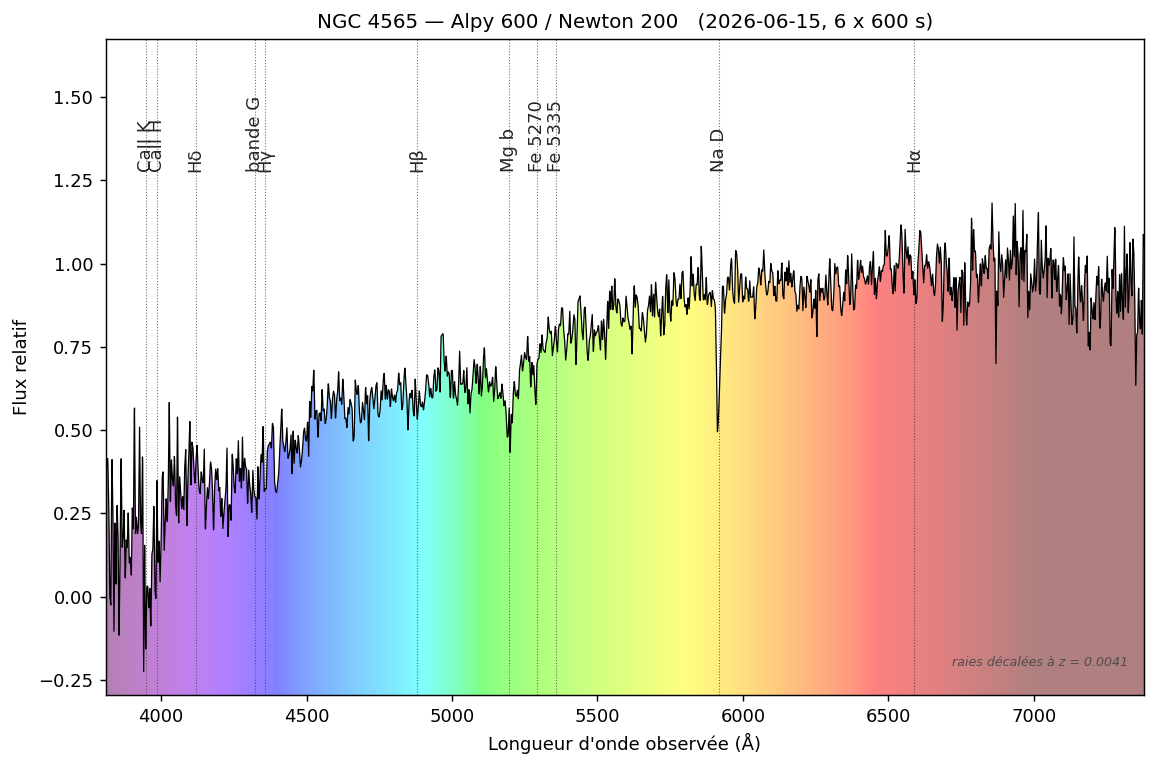

Figure enregistrée : ngc4565_spectre_couleur.png


In [28]:
fig, ax = plt.subplots(figsize=(9, 6), dpi=130)

ymin, ymax = np.nanmin(flux), np.nanmax(flux)
pad  = 0.05 * (ymax - ymin)
base = ymin - pad   # ligne de base du remplissage

# --- Dégradé couleur physique (Bruton), clippé sous la courbe ---
grad = rgb_at(wl)[None, :, :]               # (1, N, 3)
im = ax.imshow(grad, extent=[wl[0], wl[-1], base, ymax + pad],
               aspect="auto", alpha=0.5, zorder=1, interpolation="bilinear")

# clip-path = polygone fermé sous la courbe (spectre -> base -> retour)
poly = np.vstack([np.column_stack([wl, flux]),
                  [wl[-1], base],
                  [wl[0],  base]])
clip = PathPatch(Path(poly), transform=ax.transData, facecolor="none", edgecolor="none")
ax.add_patch(clip)
im.set_clip_path(clip)

# --- Spectre ---
ax.plot(wl, flux, color="k", lw=0.7, zorder=3)

# --- Raies annotées ---
ytop = ymax + pad
for name, rest in LINES:
    lam = obs(rest)
    if not (wl[0] < lam < wl[-1]):
        continue
    ax.axvline(lam, color="0.20", ls=":", lw=0.6, alpha=0.7, zorder=2)
    ax.text(lam, ytop + pad*0.3, name, rotation=90, ha="center", va="bottom",
            fontsize=10, color="0.15")

ax.set_xlim(wl[0], wl[-1])
ax.set_ylim(base, ytop + pad*6.0)
ax.set_xlabel("Longueur d'onde observée (Å)")
ax.set_ylabel("Flux relatif")
ax.set_title(f"NGC 4565 — Alpy 600 / Newton 200   "
             f"({hdr.get('DATE-OBS','')[:10]}, {hdr.get('EXPTIME2','')})",
             fontsize=11)

# petit label z discret
ax.text(0.985, 0.04, f"raies décalées à z = {z:.4f}",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=7,
        color="0.3", style="italic")

plt.tight_layout()
plt.savefig("ngc4565_spectre_couleur.png", dpi=200, bbox_inches="tight")
plt.show()
print("Figure enregistrée : ngc4565_spectre_couleur.png")


## 6. Notes

- Le rendu couleur est **qualitatif** : il illustre la teinte perçue de chaque longueur d'onde, pas l'énergie réellement reçue. L'intensité de la courbe reste le flux relatif du FITS, tracé tel quel.
- La série de Balmer et CaII H&K en absorption signent la population stellaire vieille dominante de cette galaxie vue par la tranche ; une éventuelle émission Hα (raies HII des régions de formation d'étoiles) apparaîtrait par-dessus le creux d'absorption stellaire.
- L'indice **D4000** (rupture du continuum à 4000 Å au repos : rapport des flux moyens d'une fenêtre rouge sur une fenêtre bleue de part et d'autre de 4000 Å) est un traceur d'âge de la population stellaire. Il n'est pas figuré ici mais pourra être calculé quantitativement dans l'étape d'analyse. La dépression côté bleu, bien visible sur ce spectre, vient de l'accumulation de raies métalliques (CaII H&K + forêt de Fe) typique des populations vieilles.
- **Mg b** (5175 Å) et les bandes **Fe 5270 / Fe 5335** forment, dans le système d'indices de Lick/IDS, l'indice composite **[MgFe]** qui permet de séparer l'effet de l'âge de celui de la métallicité (et de contraindre le rapport d'abondance [α/Fe]). À R ≈ 500, elles ne sont pas résolues individuellement mais apparaissent comme dépression du continuum autour de Mg b.

Pour publication web : `ngc4565_spectre_couleur.png` (200 dpi).


##7. Analyse du spectre

In [29]:
# =====================================================================
#  ANALYSE POPULATION STELLAIRE — préambule commun
#  (bruit par pixel, pseudo-continuum, dépendances)
# =====================================================================
from scipy.optimize import curve_fit

# axe au repos (les bandes/raies sont définies en longueur d'onde de repos)
wr = wl / (1 + z)

# Vecteur de bruit par pixel, estimé localement par le scatter haute fréquence.
# Sert à propager l'incertitude par Monte Carlo dans les analyses suivantes.
def _make_noise(window=80):
    s = np.zeros(len(wl))
    for i in range(len(wl)):
        lo, hi = max(0, i - window), min(len(wl), i + window)
        s[i] = np.nanstd(np.diff(flux[lo:hi])) / np.sqrt(2)
    return s

SIG = _make_noise()
_rng = np.random.default_rng(42)

def pseudo_continuum(cont_blue, cont_red, f=None):
    """Droite passant par la médiane de deux fenêtres latérales (repère de repos)."""
    if f is None:
        f = flux
    mb = (wr >= cont_blue[0]) & (wr <= cont_blue[1])
    mr = (wr >= cont_red[0])  & (wr <= cont_red[1])
    xb, yb = np.median(wr[mb]), np.median(f[mb])
    xr, yr = np.median(wr[mr]), np.median(f[mr])
    slope = (yr - yb) / (xr - xb)
    return yb + slope * (wr - xb)

print(f"Bruit médian par pixel : {np.median(SIG):.4f}  "
      f"(bleu ~{np.median(SIG[wr<4300]):.3f}, rouge ~{np.median(SIG[wr>5000]):.3f})")

Bruit médian par pixel : 0.0106  (bleu ~0.023, rouge ~0.010)


In [30]:
# =====================================================================
#  1. Amplitude du 4000 A break — version "rouge" (bandes bien mesurées)
# =====================================================================
# Le Dn4000 standard a sa bande bleue (3850-3950 A) tout au bord du domaine
# de l'Alpy, en régime de faible flux/faible S/N -> valeur non fiable ici.
# On mesure donc un indicateur INTERNE du saut, à partir de deux bandes
# propres au-dessus de 4000 A. Non comparable à la littérature Kauffmann 2003,
# mais robuste et suffisant pour signer une population vieille.

def break4000_red(f):
    lo = np.nanmean(f[(wr >= 4000) & (wr <= 4050)])   # juste après le saut
    hi = np.nanmean(f[(wr >= 4150) & (wr <= 4250)])   # plateau rouge
    return hi / lo

mc = np.array([break4000_red(flux + _rng.normal(0, SIG)) for _ in range(3000)])
R_red = np.median(mc)
print(f"R_red = <4150-4250> / <4000-4050> = {R_red:.3f} ± {np.std(mc):.3f}")

# Dn4000 standard, affiché seulement à titre indicatif (bande bleue bas-S/N)
def dn4000_std(f):
    Fnu = f * wr**2
    b = np.nanmean(Fnu[(wr >= 3850) & (wr <= 3950)])
    r = np.nanmean(Fnu[(wr >= 4000) & (wr <= 4100)])
    return r / b

mc2 = np.array([dn4000_std(flux + _rng.normal(0, SIG)) for _ in range(3000)])
print(f"Dn4000 (standard) ≈ {np.median(mc2):.2f} ± {np.std(mc2):.2f}  "
      f"[INDICATIF — bande bleue en régime bas-S/N, valeur biaisée haute]")

print("\nInterprétation : le saut du continuum à 4000 Å est nettement détecté "
      "(présence du break de Balmer/CaII), cohérent avec une population "
      "stellaire vieille dominante — attendu pour le bulbe d'une Sb vue par la tranche. "
      "La valeur numérique de Dn4000 n'est pas exploitable pour dater précisément "
      "la population avec cette acquisition (bleu non optimisé).")

R_red = <4150-4250> / <4000-4050> = 0.935 ± 0.010
Dn4000 (standard) ≈ 2.49 ± 0.06  [INDICATIF — bande bleue en régime bas-S/N, valeur biaisée haute]

Interprétation : le saut du continuum à 4000 Å est nettement détecté (présence du break de Balmer/CaII), cohérent avec une population stellaire vieille dominante — attendu pour le bulbe d'une Sb vue par la tranche. La valeur numérique de Dn4000 n'est pas exploitable pour dater précisément la population avec cette acquisition (bleu non optimisé).


In [31]:
# =====================================================================
#  2. Largeurs équivalentes (EW) de raies dans la zone propre (S/N ~4-5)
# =====================================================================
# EW "maison" (pseudo-continuum local), avec incertitude Monte Carlo.
# NON calibrées au système Lick (pas d'étoiles standard Lick dans ce run,
# et R≈500 < R_Lick), mais quantitatives et reproductibles.
# Convention : EW > 0 = absorption.

def measure_ew(center, half, cont_blue, cont_red, f):
    cont = pseudo_continuum(cont_blue, cont_red, f)
    m = (wr >= center - half) & (wr <= center + half)
    dl = np.gradient(wr)
    return np.nansum((1 - f[m] / cont[m]) * dl[m])

#   nom          centre  demi-largeur  fenêtre_bleue   fenêtre_rouge   (repos, Å)
EW_LINES = [
    ("G-band (CH) 4304", 4304.4, 20, (4270, 4285), (4330, 4345)),
    ("Hβ 4861",          4861.3, 18, (4800, 4830), (4890, 4920)),
    ("Mg b 5175",        5175.0, 25, (5120, 5145), (5210, 5230)),
    ("Na D 5893",        5892.9, 18, (5840, 5865), (5920, 5945)),
]

print(f"{'Raie':22s} {'EW (Å)':>10s}   (+ = absorption)")
print("-" * 46)
EW_results = {}
for name, ctr, half, cb, cr in EW_LINES:
    mc = np.array([measure_ew(ctr, half, cb, cr, flux + _rng.normal(0, SIG))
                   for _ in range(2000)])
    EW_results[name] = (np.median(mc), np.std(mc))
    print(f"{name:22s} {np.median(mc):6.2f} ± {np.std(mc):.2f}")

print("\nLecture : Na D et Mg b marqués + G-band présent = population évoluée, "
      "métallique. Hβ modérée en absorption (sensible à l'âge). "
      "Un remplissage éventuel de Hβ par de l'émission réduirait l'EW mesurée.")

Raie                       EW (Å)   (+ = absorption)
----------------------------------------------
G-band (CH) 4304         4.28 ± 0.50
Hβ 4861                  2.54 ± 0.15
Mg b 5175                7.27 ± 0.17
Na D 5893                6.83 ± 0.12

Lecture : Na D et Mg b marqués + G-band présent = population évoluée, métallique. Hβ modérée en absorption (sensible à l'âge). Un remplissage éventuel de Hβ par de l'émission réduirait l'EW mesurée.


Rapport de flux (4300-4500)/(6300-6500) = 0.462  (< 1 : spectre rouge, dominé par étoiles froides G-K)
T_couleur effective ≈ 4017 K  [INDICATIF : correspond à un spectre intégré de type G-K, typique d'un bulbe]


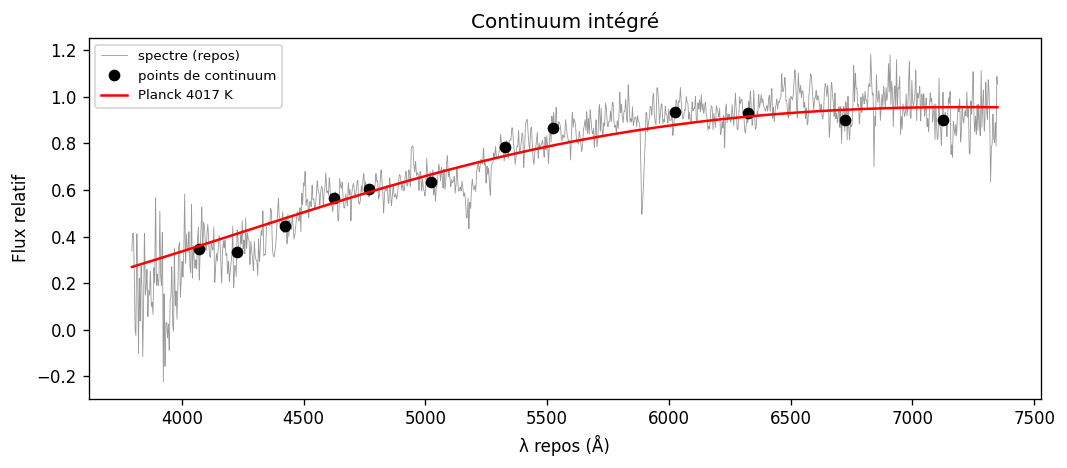

In [32]:
# =====================================================================
#  3. Forme du continuum : couleur intégrée & température effective
# =====================================================================
# La forme globale (bleu faible -> pic rouge) reflète le mélange stellaire
# intégré dans la fente. Deux estimateurs :
#   (a) un rapport de flux bleu/rouge (robuste, sans hypothèse)
#   (b) un ajustement de Planck (INDICATIF : le flux n'est pas absolu,
#       la "température de couleur" n'est qu'une paramétrisation de la pente).

ratio_BR = (np.nanmedian(flux[(wr >= 4300) & (wr <= 4500)]) /
            np.nanmedian(flux[(wr >= 6300) & (wr <= 6500)]))
print(f"Rapport de flux (4300-4500)/(6300-6500) = {ratio_BR:.3f}  "
      f"(< 1 : spectre rouge, dominé par étoiles froides G-K)")

# fenêtres de continuum ~ libres de raies fortes
cont_wins = [(4050, 4090), (4200, 4250), (4400, 4450), (4600, 4650),
             (4750, 4790), (5000, 5050), (5300, 5350), (5500, 5550),
             (6000, 6050), (6300, 6350), (6700, 6750), (7100, 7150)]
xc = np.array([np.mean(wr[(wr>=a)&(wr<=b)])       for a,b in cont_wins])
yc = np.array([np.nanmedian(flux[(wr>=a)&(wr<=b)]) for a,b in cont_wins])

def planck(l_ang, T, A):
    l = l_ang * 1e-10; hc = 1.986e-25; kB = 1.381e-23
    return A * (1/l**5) / (np.exp(hc/(l*kB*T)) - 1)

try:
    p, _ = curve_fit(planck, xc, yc, p0=[4500, 1e-30], maxfev=10000)
    print(f"T_couleur effective ≈ {p[0]:.0f} K  "
          f"[INDICATIF : correspond à un spectre intégré de type G-K, "
          f"typique d'un bulbe]")
except Exception as e:
    print("Ajustement de Planck non convergé :", e)

plt.figure(figsize=(9,4), dpi=120)
plt.plot(wr, flux, color="0.6", lw=0.5, label="spectre (repos)")
plt.plot(xc, yc, "ko", label="points de continuum")
ll = np.linspace(wr.min(), wr.max(), 300)
try:
    plt.plot(ll, planck(ll, *p), "r-", lw=1.5, label=f"Planck {p[0]:.0f} K")
except Exception:
    pass
plt.xlabel("λ repos (Å)"); plt.ylabel("Flux relatif")
plt.legend(fontsize=8); plt.title("Continuum intégré"); plt.tight_layout(); plt.show()

Résidu moyen au cœur Hα (flux - continuum) = -0.056
EW(Hα) nette = +0.92 Å   (+ = absorption, − = émission)
→ absorption stellaire dominante (peu/pas d'émission)


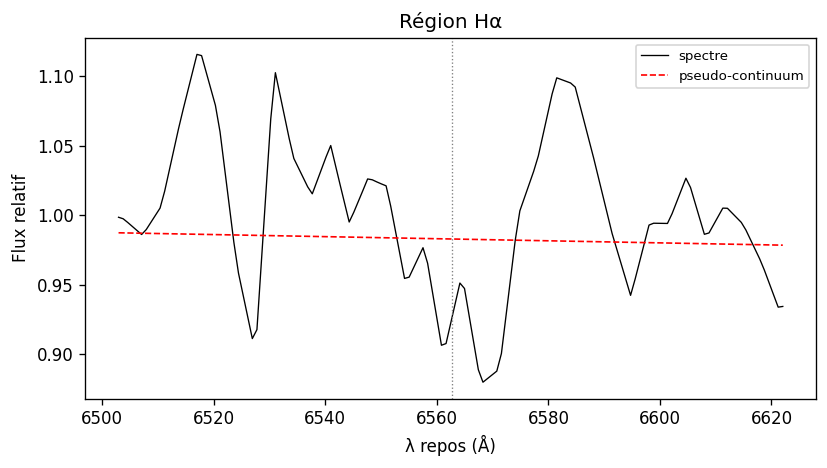


Note : à R≈500 et pour un spectre vraisemblablement dominé par le bulbe, une absorption dominante est attendue. Un léger remplissage de Hα (et le décalage du centroïde vu en analyse 5) suggère une petite contribution d'émission — à confirmer avec un meilleur S/N.


In [33]:
# =====================================================================
#  4. Hα : absorption stellaire pure ou remplissage par émission ?
# =====================================================================
# Selon ce que la fente a intégré (bulbe seul vs disque avec régions HII),
# Hα peut être en absorption pure (population vieille) ou partiellement
# rempli / en émission (formation d'étoiles). On compare le cœur de la raie
# au pseudo-continuum stellaire local.

ha = 6562.8
cont = pseudo_continuum((6480, 6520), (6600, 6640))
core = (wr >= ha - 8) & (wr <= ha + 8)
core_resid = np.nanmean(flux[core] - cont[core])

dl = np.gradient(wr)
mint = (wr >= ha - 14) & (wr <= ha + 14)
ew_ha = np.nansum((1 - flux[mint] / cont[mint]) * dl[mint])

print(f"Résidu moyen au cœur Hα (flux - continuum) = {core_resid:+.3f}")
print(f"EW(Hα) nette = {ew_ha:+.2f} Å   (+ = absorption, − = émission)")
if core_resid < -0.02:
    verdict = "absorption stellaire dominante (peu/pas d'émission)"
elif core_resid > 0.02:
    verdict = "émission détectée au-dessus du continuum (régions HII dans la fente)"
else:
    verdict = "cœur proche du continuum : absorption possiblement remplie par émission"
print("→", verdict)

plt.figure(figsize=(7,4), dpi=120)
w = (wr >= ha - 60) & (wr <= ha + 60)
plt.plot(wr[w], flux[w], "k-", lw=0.8, label="spectre")
plt.plot(wr[w], cont[w], "r--", lw=1, label="pseudo-continuum")
plt.axvline(ha, color="0.5", ls=":", lw=0.8)
plt.xlabel("λ repos (Å)"); plt.ylabel("Flux relatif")
plt.title("Région Hα"); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

print("\nNote : à R≈500 et pour un spectre vraisemblablement dominé par le bulbe, "
      "une absorption dominante est attendue. Un léger remplissage de Hα (et le "
      "décalage du centroïde vu en analyse 5) suggère une petite contribution "
      "d'émission — à confirmer avec un meilleur S/N.")

Raie      v (km/s)  σ_bruit  type              
------------------------------------------------
CaII K       1192  ±  13   raie simple       
Hβ           1192  ±  14   raie simple       
Mg b         1224  ±   7   multiplet         
Na D         1165  ±   4   multiplet         
Hα           1332  ±  12   émission possible 
------------------------------------------------

Deux budgets d'incertitude :
  • bruit (MC, typique par raie) : ±12 km/s
  • dispersion inter-raies       : ±59 km/s

  → dispersion inter-raies >> bruit : les écarts entre raies sont RÉELS
    (barycentre des multiplets Mg b/Na D, remplissage d'émission de Hα),
    pas du bruit de mesure.

Estimation de la vitesse héliocentrique :
  • toutes raies          : 1192 ± 59 km/s
  • raies simples seules  : 1192 km/s  (CaII K, Hβ — les plus propres)
  • référence NED         : 1230 km/s

Les raies simples, non affectées par le blending ni l'émission, donnent l'estimateur
le plus fiable. Hα, décalé vers le rouge, signe ind

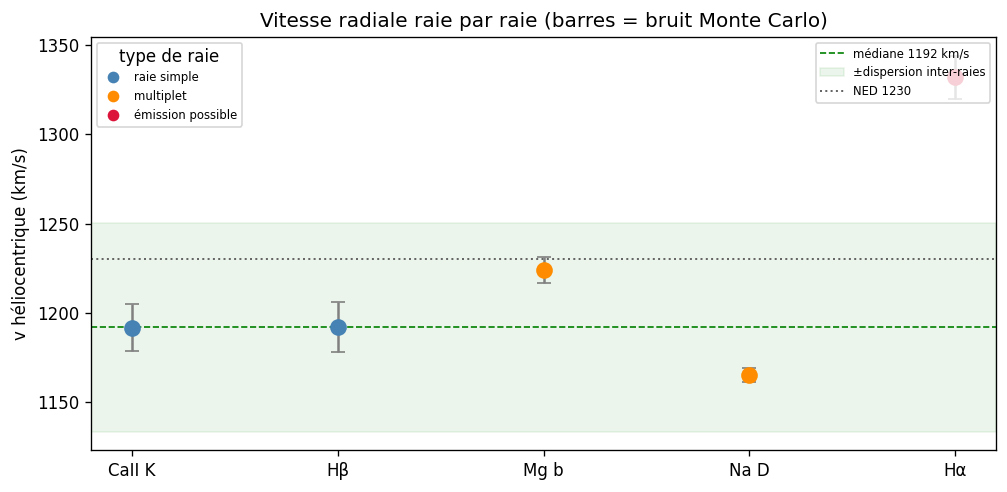

In [34]:
# =====================================================================
#  5. Redshift raie par raie — avec barres d'erreur Monte Carlo
# =====================================================================
# Le centroïde de chaque raie donne un décalage, mais deux sources
# d'incertitude très différentes coexistent :
#   - le BRUIT (aléatoire) : quantifié par Monte Carlo, en rejouant la
#     mesure en ajoutant N(0, SIG) au flux. Donne σ_bruit par raie.
#   - les SYSTÉMATIQUES (physiques) : barycentre d'un multiplet non résolu
#     (Mg b, Na D) ou remplissage d'une absorption par de l'émission (Hα).
#     Se lisent dans la DISPERSION entre raies, pas dans le bruit.
# On sépare explicitement ces deux budgets plutôt que de les confondre.
# Les vitesses sont corrigées de la rotation terrestre (V_CORR, cellule 4b),
# donc exprimées dans le repère héliocentrique, comparables à NED.

# Redéfinition avec argument flux optionnel (nécessaire pour le Monte Carlo)
def pseudo_continuum(cont_blue, cont_red, f=None):
    if f is None:
        f = flux
    mb = (wr >= cont_blue[0]) & (wr <= cont_blue[1])
    mr = (wr >= cont_red[0])  & (wr <= cont_red[1])
    xb, yb = np.median(wr[mb]), np.median(f[mb])
    xr, yr = np.median(wr[mr]), np.median(f[mr])
    slope = (yr - yb) / (xr - xb)
    return yb + slope * (wr - xb)

def line_centroid(rest, half, cont_blue, cont_red, f=None):
    if f is None:
        f = flux
    cont = pseudo_continuum(cont_blue, cont_red, f)
    win = (wr >= rest - half) & (wr <= rest + half)
    depth = np.clip(cont[win] - f[win], 0, None)
    if depth.sum() <= 0:
        return np.nan
    return np.sum(wl[win] * depth) / np.sum(depth)

#   nom      repos     demi-win  fenêtre_bleue   fenêtre_rouge   type
Z_LINES = [
    ("CaII K", 3933.66, 12, (3890, 3910), (3990, 4010), "raie simple"),
    ("Hβ",     4861.33, 12, (4800, 4830), (4890, 4920), "raie simple"),
    ("Mg b",   5175.00, 18, (5120, 5145), (5210, 5230), "multiplet"),
    ("Na D",   5892.90, 14, (5840, 5865), (5920, 5945), "multiplet"),
    ("Hα",     6562.80, 14, (6480, 6520), (6600, 6640), "émission possible"),
]
N_MC = 2000

print(f"{'Raie':8s} {'v (km/s)':>9s} {'σ_bruit':>8s}  {'type':<18s}")
print("-" * 48)

names, vv, ss, types = [], [], [], []
for name, rest, half, cb, cr, typ in Z_LINES:
    mu0 = line_centroid(rest, half, cb, cr)
    v0  = (mu0 / rest - 1) * C_LIGHT + V_CORR   # topocentrique -> héliocentrique
    # Monte Carlo : dispersion du centroïde sous le bruit
    mus = np.array([line_centroid(rest, half, cb, cr, flux + _rng.normal(0, SIG))
                    for _ in range(N_MC)])
    sv = np.std(mus / rest - 1) * C_LIGHT   # la correction est constante => n'affecte pas sigma
    names.append(name); vv.append(v0); ss.append(sv); types.append(typ)
    print(f"{name:8s} {v0:8.0f}  ±{sv:4.0f}   {typ:<18s}")

vv, ss = np.array(vv), np.array(ss)

# --- Deux budgets d'incertitude ---
v_med          = np.median(vv)
sig_noise_typ  = np.median(ss)      # bruit typique par raie
sig_interline  = np.std(vv)         # dispersion entre raies (systématiques)
v_simple       = np.median([v for v, t in zip(vv, types) if t == "raie simple"])

print("-" * 48)
print(f"\nDeux budgets d'incertitude :")
print(f"  • bruit (MC, typique par raie) : ±{sig_noise_typ:.0f} km/s")
print(f"  • dispersion inter-raies       : ±{sig_interline:.0f} km/s")
if sig_interline > 2 * sig_noise_typ:
    print(f"\n  → dispersion inter-raies >> bruit : les écarts entre raies sont "
          f"RÉELS\n    (barycentre des multiplets Mg b/Na D, remplissage d'émission "
          f"de Hα),\n    pas du bruit de mesure.")

print(f"\nEstimation de la vitesse héliocentrique :")
print(f"  • toutes raies          : {v_med:.0f} ± {sig_interline:.0f} km/s")
print(f"  • raies simples seules  : {v_simple:.0f} km/s  (CaII K, Hβ — les plus propres)")
print(f"  • référence NED         : {V_HELIO:.0f} km/s")
print(f"\nLes raies simples, non affectées par le blending ni l'émission, "
      f"donnent l'estimateur\nle plus fiable. Hα, décalé vers le rouge, signe "
      f"indirectement une composante d'émission.")

# --- Graphe : v par raie, barres = bruit MC, code couleur par type ---
import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(8.5, 4.2), dpi=120)
xpos = np.arange(len(names))
cmap = {"raie simple": "steelblue", "multiplet": "darkorange",
        "émission possible": "crimson"}

for x, v, s, t in zip(xpos, vv, ss, types):
    ax.errorbar(x, v, yerr=s, fmt="o", ms=9, color=cmap[t],
                ecolor="gray", capsize=4, zorder=3)

ax.axhline(v_med, color="green", ls="--", lw=1, label=f"médiane {v_med:.0f} km/s")
ax.axhspan(v_med - sig_interline, v_med + sig_interline,
           color="green", alpha=0.08, label="±dispersion inter-raies")
ax.axhline(V_HELIO, color="0.4", ls=":", lw=1.2, label=f"NED {V_HELIO:.0f}")

handles = [mlines.Line2D([], [], marker="o", ls="", color=c, label=l)
           for l, c in cmap.items()]
leg1 = ax.legend(handles=handles, fontsize=7, loc="upper left", title="type de raie")
ax.add_artist(leg1)
ax.legend(fontsize=7, loc="upper right")

ax.set_xticks(xpos); ax.set_xticklabels(names)
ax.set_ylabel("v héliocentrique (km/s)")
ax.set_title("Vitesse radiale raie par raie (barres = bruit Monte Carlo)")
plt.tight_layout()
plt.savefig("ngc4565_vitesse_raies.png", dpi=200, bbox_inches="tight")
plt.show()

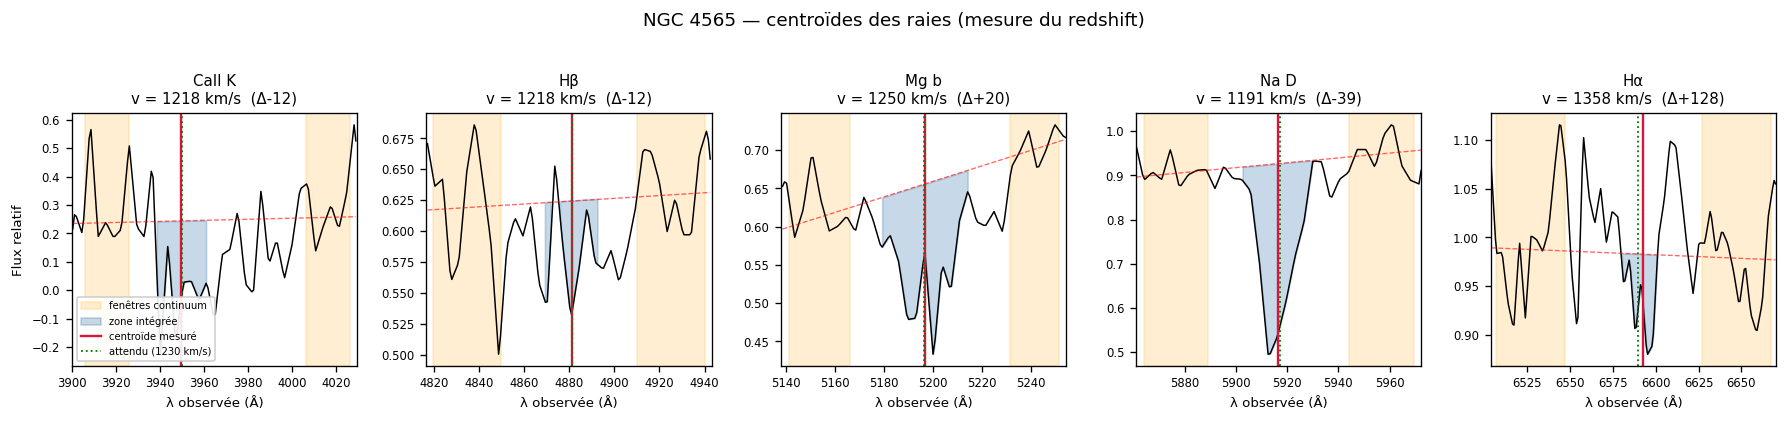

In [35]:
# =====================================================================
#  5b. Visualisation des centroïdes raie par raie
# =====================================================================
# Un panneau par raie : spectre, pseudo-continuum, fenêtres latérales
# utilisées pour l'ajuster (orange), zone d'absorption intégrée (bleu),
# centroïde mesuré (rouge) et position attendue à v_réf (vert).

fig, axes = plt.subplots(1, len(Z_LINES), figsize=(3*len(Z_LINES), 3.4), dpi=120)

for ax, (name, rest, half, cb, cr, _typ) in zip(axes, Z_LINES):
    mu   = line_centroid(rest, half, cb, cr)
    zi   = mu / rest - 1
    obs0 = rest * (1 + z)                      # position attendue (v de référence)
    cont = pseudo_continuum(cb, cr)

    # vue adaptée pour englober les deux fenêtres de continuum
    lo_view = min(obs0 - 50, cb[0]*(1+z) - 3)
    hi_view = max(obs0 + 50, cr[1]*(1+z) + 3)
    w = (wl >= lo_view) & (wl <= hi_view)

    ax.plot(wl[w], flux[w], "k-", lw=0.9)
    ax.plot(wl[w], cont[w], "r--", lw=0.8, alpha=0.6)

    # fenêtres de pseudo-continuum (converties repos -> observé)
    for j, (lo, hi) in enumerate([cb, cr]):
        ax.axvspan(lo*(1+z), hi*(1+z), color="orange", alpha=0.18,
                   label="fenêtres continuum" if j == 0 else None)

    # zone d'absorption effectivement intégrée pour le centroïde
    win = (wl >= mu - half) & (wl <= mu + half)
    ax.fill_between(wl[win], flux[win], cont[win],
                    where=(flux[win] < cont[win]),
                    color="steelblue", alpha=0.30,
                    label="zone intégrée")

    ax.axvline(mu,   color="crimson", lw=1.4, label="centroïde mesuré")
    ax.axvline(obs0, color="green", ls=":", lw=1.1,
               label=f"attendu ({V_HELIO:.0f} km/s)")

    dv = (mu - obs0) / obs0 * C_LIGHT          # écart en vitesse vs référence
    ax.set_title(f"{name}\nv = {zi*C_LIGHT:.0f} km/s  (Δ{dv:+.0f})", fontsize=9)
    ax.set_xlabel("λ observée (Å)", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.set_xlim(lo_view, hi_view)

axes[0].set_ylabel("Flux relatif", fontsize=8)
axes[0].legend(fontsize=6, loc="lower left", framealpha=0.9)

fig.suptitle("NGC 4565 — centroïdes des raies (mesure du redshift)",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig("ngc4565_centroides_raies.png", dpi=200, bbox_inches="tight")
plt.show()

In [42]:
# =====================================================================
#  CCF — Vitesse radiale par corrélation croisée avec templates K
# =====================================================================
# Méthode de Tonry & Davis (1979) simplifiée, adaptée à R≈500 :
#   - mise à plat du continuum (division par polynôme bas degré)
#   - rééchantillonnage en log-λ (décalage constant en log λ = vitesse)
#   - apodisation cosinus des bords (anti-artefacts de FFT)
#   - corrélation, ajustement gaussien du pic
#   - qualité : R de Tonry-Davis + erreur Monte Carlo
# On compare plusieurs types spectraux K pour voir lequel corrèle le
# mieux avec le bulbe (population vieille) de NGC 4565.

import glob, re

# --- Domaine de corrélation (réglable) ---
CCF_MIN, CCF_MAX = 4150, 6600     # zone riche : bande G, Hβ, Mg b, Fe, Na D, Hα
# CCF_MIN, CCF_MAX = 4150, 5800
# variantes utiles : (4150, 5800) plus étroit sans Na D/Hα ; (4300, 6600) sans bord bleu

# --- Masques telluriques (bandes d'absorption atmosphérique à exclure) ---
TELLURIC = [(6860, 6890),   # bande B de O2
            (7160, 7340)]   # vapeur d'eau (si domaine étendu)

# --- Paramètres ---
CONT_DEG   = 5              # degré du polynôme de continuum
DV         = 20.0          # pas de la grille log-λ, en km/s/pixel
V_SEARCH   = (500, 2000)   # fenêtre de recherche du pic (km/s), autour de v attendue
TEMPLATE_GLOB = "p_k*.dat" # motif des fichiers Pickles (dans le dossier de travail)

print(f"Domaine CCF : {CCF_MIN}-{CCF_MAX} Å")
print(f"Masques telluriques : {TELLURIC}")
print(f"Pas vitesse : {DV} km/s | continuum : polynôme deg {CONT_DEG}")

Domaine CCF : 4150-6600 Å
Masques telluriques : [(6860, 6890), (7160, 7340)]
Pas vitesse : 20.0 km/s | continuum : polynôme deg 5


In [40]:
# --- Fonctions de la CCF -------------------------------------------------

def _ccf_mask(w):
    """Sélection du domaine CCF hors bandes telluriques."""
    m = (w >= CCF_MIN) & (w <= CCF_MAX)
    for lo, hi in TELLURIC:
        m &= ~((w >= lo) & (w <= hi))
    return m

def _flatten(w, f, deg=CONT_DEG):
    """Retire le continuum : division par un polynôme bas degré, résidu ~0."""
    m = np.isfinite(f)
    c = np.polyfit(w[m], f[m], deg)
    return f / np.polyval(c, w) - 1.0

def _taper(x, frac=0.1):
    """Apodisation cosinus des bords (10% par défaut) après retrait de la moyenne."""
    N = len(x); w = np.ones(N); k = int(N * frac)
    t = 0.5 * (1 - np.cos(np.pi * np.arange(k) / k))
    w[:k] *= t; w[-k:] *= t[::-1]
    return (x - x.mean()) * w

def compute_ccf(gflux, twl, tfl):
    """CCF entre le spectre galaxie (gflux, sur wl) et un template (twl, tfl)."""
    mg = _ccf_mask(wl); mt = _ccf_mask(twl)
    gwl, gfl = wl[mg],  _flatten(wl, gflux)[mg]
    twl2, tfl2 = twl[mt], _flatten(twl, tfl)[mt]
    lo = max(gwl.min(), twl2.min()); hi = min(gwl.max(), twl2.max())
    dlog = DV / C_LIGHT
    logw = np.arange(np.log(lo), np.log(hi), dlog)
    gg = _taper(np.interp(np.exp(logw), gwl,  gfl))
    tt = _taper(np.interp(np.exp(logw), twl2, tfl2))
    ccf = np.correlate(gg, tt, mode="full")
    ccf /= np.sqrt(np.sum(gg**2) * np.sum(tt**2))
    vel = np.arange(-len(gg) + 1, len(gg)) * DV   # km/s (topocentrique)
    return vel, ccf

def peak_velocity(vel, ccf):
    """Vitesse du pic CCF par ajustement gaussien dans la fenêtre de recherche."""
    srch = (vel > V_SEARCH[0]) & (vel < V_SEARCH[1])
    ipk = np.argmax(ccf[srch]); vpk = vel[srch][ipk]
    def _g(x, a, mu, s, c): return c + a * np.exp(-0.5 * ((x - mu) / s)**2)
    sel = (vel > vpk - 300) & (vel < vpk + 300)
    try:
        p, _ = curve_fit(_g, vel[sel], ccf[sel], p0=[ccf[srch][ipk], vpk, 120, 0])
        return p[1], p[0], abs(p[2])     # vitesse, hauteur pic, largeur
    except Exception:
        return vpk, ccf[srch][ipk], np.nan

def tonry_davis_R(vel, ccf, vpk):
    """Indicateur de qualité R (Tonry & Davis 1979) : pic / bruit d'antisymétrie."""
    h = np.max(ccf)
    ip = np.argmin(np.abs(vel - vpk))
    half = min(ip, len(ccf) - ip - 1)
    a = ccf[ip-half:ip+half+1]
    anti = a - (a + a[::-1]) / 2       # part antisymétrique = bruit
    rms = np.std(anti)
    return h / (np.sqrt(2) * rms) if rms > 0 else np.nan

def parse_type(fn):
    """p_k2iii.dat -> 'K2 III' ; p_k01ii.dat -> 'K0/1 II'."""
    b = fn.split("/")[-1].replace("p_k", "").replace(".dat", "")
    m = re.match(r"(\d+)([iv]+)", b)
    if not m:
        return fn
    num, lum = m.group(1), m.group(2).upper()
    t = f"K{num[0]}/{num[1]}" if len(num) == 2 else f"K{num}"
    return f"{t} {lum}"

In [43]:
# --- Boucle sur tous les templates K + tableau récapitulatif -------------
# Rappel : V_CORR (cellule 4b) ramène la vitesse topocentrique en héliocentrique.

template_files = sorted(glob.glob(TEMPLATE_GLOB))
if not template_files:
    raise FileNotFoundError(f"Aucun fichier {TEMPLATE_GLOB} dans le dossier de travail.")
print(f"{len(template_files)} templates trouvés.\n")

N_MC_CCF = 200
ccf_results = []

print(f"{'Type':10s} {'v_hélio':>8s} {'σ_MC':>6s} {'pic':>6s} {'R_TD':>6s} {'largeur':>8s}")
print("-" * 52)
for tf in template_files:
    d = np.loadtxt(tf); twl, tfl = d[:, 0], d[:, 1]
    vel, ccf = compute_ccf(flux, twl, tfl)
    v0, pk, wd = peak_velocity(vel, ccf)
    R = tonry_davis_R(vel, ccf, v0)

    # erreur Monte Carlo (bruit ajouté au spectre galaxie)
    vs = []
    for _ in range(N_MC_CCF):
        vmc, _, _ = peak_velocity(*compute_ccf(flux + _rng.normal(0, SIG), twl, tfl))
        vs.append(vmc)
    sv = np.std(vs)

    vhel = v0 + V_CORR
    ccf_results.append(dict(type=parse_type(tf), file=tf, v=vhel, sig=sv,
                            peak=pk, R=R, width=wd, vel=vel, ccf=ccf))
    print(f"{parse_type(tf):10s} {vhel:8.0f} {sv:6.0f} {pk:6.3f} {R:6.1f} {wd:8.0f}")

# meilleur template = plus grand R de Tonry-Davis
best = max(ccf_results, key=lambda r: r["R"])
vv_all = np.array([r["v"] for r in ccf_results])
print("-" * 52)
print(f"\nMeilleur template (R max) : {best['type']}  "
      f"→ v = {best['v']:.0f} ± {best['sig']:.0f} km/s  (R={best['R']:.1f})")
print(f"Vitesse médiane sur tous les templates : {np.median(vv_all):.0f} "
      f"± {np.std(vv_all):.0f} km/s")
print(f"Référence NED : {V_HELIO:.0f} km/s")
print(f"\n(La dispersion entre templates reflète la sensibilité au choix de "
      f"population stellaire de référence.)")

19 templates trouvés.

Type        v_hélio   σ_MC    pic   R_TD  largeur
----------------------------------------------------
K0/1 II        1024      5  0.264    6.3      504
K0 III         1092      8  0.154   10.1      688
K0 IV          1080      6  0.150   10.9      586
K0 V            990      6  0.245   11.8      847
K1 III         1105      8  0.124    8.8      569
K1 IV          1266      8  0.076    7.4      527
K2 I           1071      3  0.219    4.5      449
K2 III         1053      4  0.255   15.7      425
K2 V            988      6  0.165   16.4      593
K3 I           1039      3  0.200    7.7      388
K3 III          911      6  0.116    8.8      569
K3 IV          1180      8  0.172    9.9      700
K3 V           1119      3  0.258   14.2      549
K4 I           1029      3  0.233    6.5      421
K4 III         1051      4  0.328    7.8      588
K4 V           1070      4  0.239   23.7      548
K5 III          906      6  0.369   12.7      951
K5 V            894     

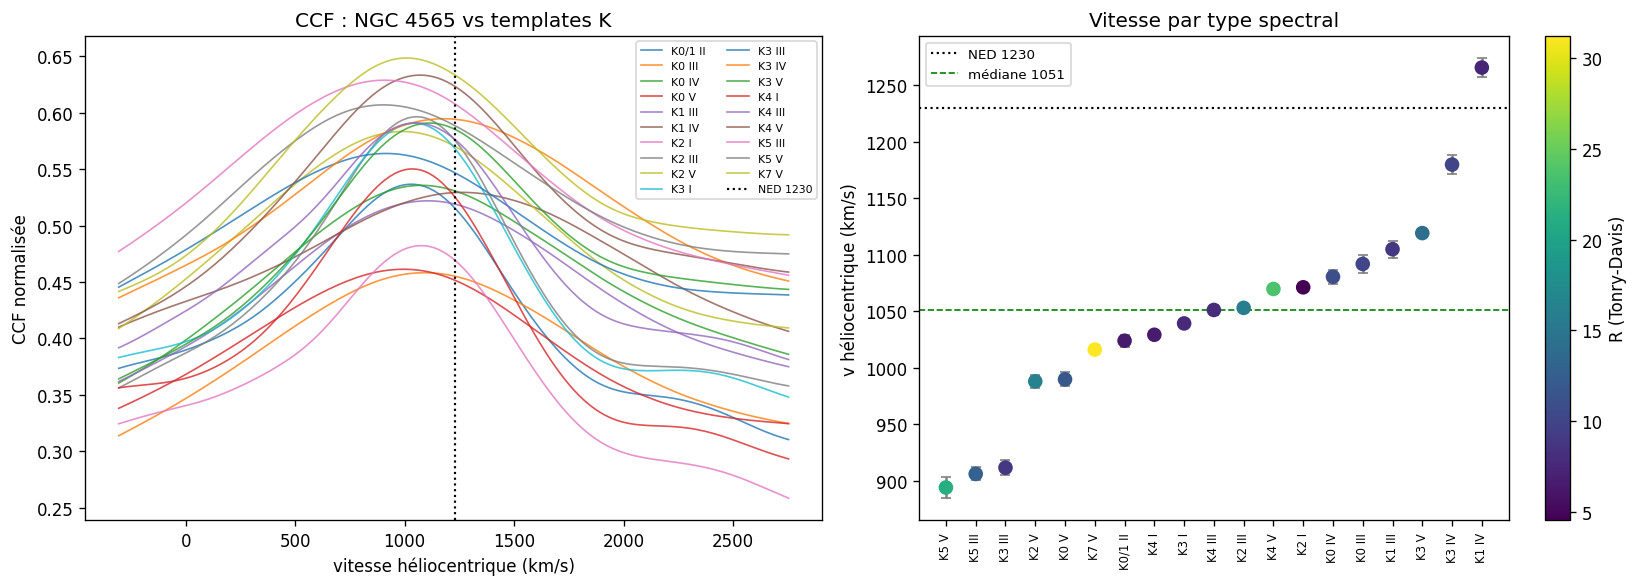

In [44]:
# --- Graphes : CCF superposées + vitesse par type ------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# (a) CCF superposées
for r in ccf_results:
    m = (r["vel"] > -300) & (r["vel"] < 2800)
    ax1.plot(r["vel"][m] + V_CORR, r["ccf"][m], lw=1, alpha=0.8, label=r["type"])
ax1.axvline(V_HELIO, color="k", ls=":", lw=1.3, label=f"NED {V_HELIO:.0f}")
ax1.set_xlabel("vitesse héliocentrique (km/s)")
ax1.set_ylabel("CCF normalisée")
ax1.set_title("CCF : NGC 4565 vs templates K")
ax1.legend(fontsize=6.5, ncol=2, loc="upper right")

# (b) vitesse trouvée par type spectral, barres = erreur MC
types = [r["type"] for r in ccf_results]
vs    = np.array([r["v"] for r in ccf_results])
ss    = np.array([r["sig"] for r in ccf_results])
Rs    = np.array([r["R"] for r in ccf_results])
order = np.argsort(vs)
xpos  = np.arange(len(types))
sc = ax2.scatter(xpos, vs[order], c=Rs[order], cmap="viridis", s=60, zorder=3)
ax2.errorbar(xpos, vs[order], yerr=ss[order], fmt="none", ecolor="gray", capsize=3, zorder=2)
ax2.axhline(V_HELIO, color="k", ls=":", lw=1.3, label=f"NED {V_HELIO:.0f}")
ax2.axhline(np.median(vs), color="green", ls="--", lw=1, label=f"médiane {np.median(vs):.0f}")
ax2.set_xticks(xpos); ax2.set_xticklabels([types[i] for i in order], rotation=90, fontsize=7)
ax2.set_ylabel("v héliocentrique (km/s)")
ax2.set_title("Vitesse par type spectral")
ax2.legend(fontsize=8)
plt.colorbar(sc, ax=ax2, label="R (Tonry-Davis)")

plt.tight_layout()
plt.savefig("ngc4565_ccf.png", dpi=200, bbox_inches="tight")
plt.show()

Contrôle de calibration (CCF HD108382 obs vs Melchiors) :
  vitesse du pic CCF (brute)      = -9.5 km/s
  correction hélio de l'obs       = -28.8 km/s (attendu si calib parfaite)
  → décalage de calibration       = +19.3 km/s
    soit +0.32 Å à 5000 Å  (+0.39 pixel Alpy)
  qualité : pic=0.402, largeur=597 km/s

  → calibration excellente (< 20 km/s, < ~0.3 Å). L'écart résiduel sur NGC 4565 ne s'explique pas par la calibration.


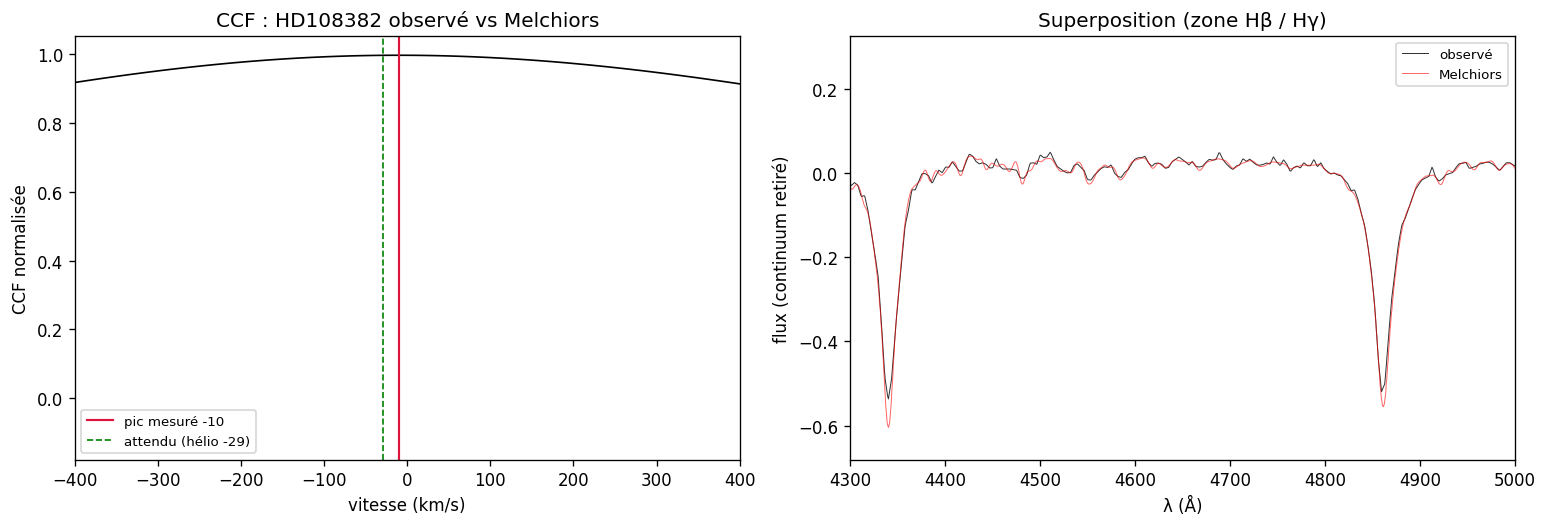

In [20]:
# =====================================================================
#  CONTRÔLE DE CALIBRATION EN LONGUEUR D'ONDE
#  CCF étoile observée (HD108382) vs référence Melchiors
# =====================================================================
# Principe : la bibliothèque Melchiors est au repos (repère stellaire).
# Ton observation de l'étoile n'est PAS corrigée de l'héliocentrique
# (BSS_VHEL=0). Si ta calibration était parfaite, la CCF donnerait
# exactement la correction héliocentrique de l'observation. Tout écart
# à cette valeur = décalage du point zéro de ta calibration.
#
# Note : HD108382 est une étoile de type A (raies de Balmer larges,
# peu de raies métalliques). La CCF globale est ici plus fiable qu'une
# mesure raie par raie (les Balmer larges piègent les centroïdes).

from astropy.coordinates import EarthLocation, SkyCoord
from astropy.time import Time
import astropy.units as u

# --- Fichiers et coordonnées de l'étoile ---
OBS_STAR      = "_hd108382_20260615_921.fits"      # ton spectre (même config Alpy)
REF_MELCHIORS = "Melchiors_HD108382_R600.fits"     # référence Melchiors
STAR_COORD    = "12h27m36s -02d50m38s"             # HD108382 (ICRS J2000)

# --- Paramètres CCF (mêmes conventions que la CCF galaxie) ---
CAL_MIN, CAL_MAX = 4150, 6600
CAL_TELLURIC = [(6860, 6890), (7160, 7340)]
CAL_DEG = 5
CAL_DV  = 10.0

def _load_fits(fn):
    hh = fits.open(fn)[0]
    ff = hh.data.astype(float); nn = hh.header["NAXIS1"]
    ww = hh.header["CRVAL1"] + (np.arange(nn) - (hh.header.get("CRPIX1", 1) - 1)) * hh.header["CDELT1"]
    return ww, ff, hh.header

owl, ofl, ohdr = _load_fits(OBS_STAR)
mwl, mfl, _    = _load_fits(REF_MELCHIORS)

def _cal_mask(w):
    m = (w >= CAL_MIN) & (w <= CAL_MAX)
    for lo, hi in CAL_TELLURIC:
        m &= ~((w >= lo) & (w <= hi))
    return m

def _cal_flatten(w, f, deg=CAL_DEG):
    m = np.isfinite(f); c = np.polyfit(w[m], f[m], deg)
    return f / np.polyval(c, w) - 1.0

def _cal_taper(x, frac=0.1):
    N = len(x); w = np.ones(N); k = int(N * frac)
    t = 0.5 * (1 - np.cos(np.pi * np.arange(k) / k))
    w[:k] *= t; w[-k:] *= t[::-1]
    return (x - x.mean()) * w

# --- CCF ---
mo, mm = _cal_mask(owl), _cal_mask(mwl)
o2, of2 = owl[mo], _cal_flatten(owl, ofl)[mo]
m2, mf2 = mwl[mm], _cal_flatten(mwl, mfl)[mm]
lo = max(o2.min(), m2.min()); hi = min(o2.max(), m2.max())
logw = np.arange(np.log(lo), np.log(hi), CAL_DV / C_LIGHT)
oo  = _cal_taper(np.interp(np.exp(logw), o2, of2))
mm_ = _cal_taper(np.interp(np.exp(logw), m2, mf2))
ccf = np.correlate(oo, mm_, mode="full")
ccf /= np.sqrt(np.sum(oo**2) * np.sum(mm_**2))
vel = np.arange(-len(oo) + 1, len(oo)) * CAL_DV

srch = (vel > -400) & (vel < 400)
ipk = np.argmax(ccf[srch]); vpk = vel[srch][ipk]
def _g(x, a, mu, s, c): return c + a * np.exp(-0.5 * ((x - mu) / s)**2)
sel = (vel > vpk - 200) & (vel < vpk + 200)
p, _ = curve_fit(_g, vel[sel], ccf[sel], p0=[ccf[srch][ipk], vpk, 80, 0])
v_ccf = p[1]

# --- Correction héliocentrique de l'observation de l'étoile ---
t_star = Time(ohdr.get("DATE-OBS"), scale="utc")
loc = EarthLocation(lat=42.94*u.deg, lon=0.14*u.deg, height=2877*u.m)
star = SkyCoord(STAR_COORD, frame="icrs")
vhelio_star = star.radial_velocity_correction(
    kind="heliocentric", obstime=t_star, location=loc).to(u.km/u.s).value

# --- Décalage de calibration ---
# Si calibration parfaite : v_ccf attendu = vhelio_star (obs non corrigée).
# offset = mesuré - attendu
calib_offset = v_ccf - vhelio_star
offset_A_5000 = calib_offset / C_LIGHT * 5000.0
offset_px     = offset_A_5000 / 0.83   # pixel Alpy ≈ 0.83 Å

print("Contrôle de calibration (CCF HD108382 obs vs Melchiors) :")
print(f"  vitesse du pic CCF (brute)      = {v_ccf:+.1f} km/s")
print(f"  correction hélio de l'obs       = {vhelio_star:+.1f} km/s (attendu si calib parfaite)")
print(f"  → décalage de calibration       = {calib_offset:+.1f} km/s")
print(f"    soit {offset_A_5000:+.2f} Å à 5000 Å  ({offset_px:+.2f} pixel Alpy)")
print(f"  qualité : pic={p[0]:.3f}, largeur={abs(p[2]):.0f} km/s")
if abs(calib_offset) < 20:
    print(f"\n  → calibration excellente (< 20 km/s, < ~0.3 Å). "
          f"L'écart résiduel sur NGC 4565 ne s'explique pas par la calibration.")
else:
    print(f"\n  → décalage notable : à prendre en compte dans les vitesses mesurées.")

# --- Graphes ---
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5), dpi=120)
a1.plot(vel, ccf, "k-", lw=1)
a1.axvline(v_ccf, color="crimson", lw=1.3, label=f"pic mesuré {v_ccf:+.0f}")
a1.axvline(vhelio_star, color="green", ls="--", lw=1,
           label=f"attendu (hélio {vhelio_star:+.0f})")
a1.set_xlim(-400, 400); a1.set_xlabel("vitesse (km/s)"); a1.set_ylabel("CCF normalisée")
a1.set_title("CCF : HD108382 observé vs Melchiors"); a1.legend(fontsize=8)

a2.plot(owl, _cal_flatten(owl, ofl), "k-", lw=0.6, alpha=0.8, label="observé")
a2.plot(mwl, _cal_flatten(mwl, mfl), "r-", lw=0.6, alpha=0.6, label="Melchiors")
a2.set_xlim(4300, 5000)
a2.set_xlabel("λ (Å)"); a2.set_ylabel("flux (continuum retiré)")
a2.set_title("Superposition (zone Hβ / Hγ)"); a2.legend(fontsize=8)

plt.tight_layout()
plt.savefig("ngc4565_controle_calibration.png", dpi=200, bbox_inches="tight")
plt.show()

## Note d'interprétation — vitesse mesurée, rotation et calibration

### Objectif initial et limite du signal

L'observation visait à **résoudre la courbe de rotation** de NGC 4565 : fente alignée sur le grand axe de la galaxie, dans le but de mesurer le décalage en vitesse (ΔV) des raies d'un bout à l'autre du disque. En pratique, le signal le long du disque est trop faible sur l'image 2D à ce rapport S/N : **seul le bulbe central fournit un spectre exploitable**. Les vitesses mesurées ici (CCF, centroïdes) correspondent donc à la lumière stellaire intégrée du **bulbe**, pas à un point précis du disque ni au centre de masse dynamique.

### Ce que valent les valeurs de référence

La vitesse systémique publiée, **1230 km/s**, est une mesure **radio HI** (relevés WSRT/GBT, ex. HALOGAS) : raie à 21 cm, fréquence de repos connue avec une précision extrême, vitesse déterminée par symétrie du profil global entre côté approchant et côté récédant. Son incertitude réelle est de l'ordre de quelques km/s. C'est un excellent étalon, mais il représente le **barycentre dynamique** de la galaxie entière.

Les ~45 mesures de redshift compilées dans NED mélangent des déterminations de qualités très diverses (HI moderne ~1230 ; HI ancienne ±10-20 km/s ; mesures optiques dépendant de la région observée). Leur dispersion ne traduit pas une incertitude sur la systémique, mais la variété des méthodes et des zones échantillonnées.

### Pourquoi l'écart mesuré n'est pas une erreur

NGC 4565 est une spirale vue quasiment par la tranche (i ≈ 86°) qui tourne vite : vitesse de rotation de pointe ~244 km/s, soit une amplitude projetée de ±243 km/s le long de la ligne de visée. Une mesure sur fente ne donne donc **pas** la systémique, sauf à être parfaitement centrée sur le noyau ou à moyenner symétriquement les deux côtés (ce que fait justement la radio HI).

Les vitesses obtenues ici :

| Méthode | v_hélio (km/s) | écart à 1230 |
|---|---|---|
| CCF (templates K, meilleurs R) | ~1050 | −180 |
| Centroïdes des raies simples (CaII K, Hβ) | ~1192 | −38 |
| Systémique HI (référence) | 1230 | — |

Les deux écarts (−38 et −180 km/s) sont **largement contenus dans l'enveloppe de rotation** (±243 km/s). Ils sont cohérents avec une extraction du bulbe légèrement décalée vers le côté qui s'approche, ou pondérée par la partie ascendante de la courbe de rotation interne. Autrement dit, ce n'est pas une erreur de mesure de la systémique : c'est une **signature réelle de la cinématique** de la galaxie, précisément la quantité que l'observation cherchait à capter, mais réduite ici au seul bulbe faute de signal sur le disque.

### Contrôle de calibration indépendant

La CCF entre l'étoile standard **HD108382** (observée dans la même configuration Alpy, même nuit) et sa référence **Melchiors** donne un décalage de calibration de **+0.3 Å à 5000 Å** (~+19 km/s, soit ~0,4 pixel Alpy). La calibration en longueur d'onde est donc excellente. Point important : cet offset est petit et de signe opposé à l'écart galaxie (il augmenterait les vitesses, alors qu'on mesure moins que la systémique). **La calibration n'est donc pas la cause de l'écart** à 1230 — ce contrôle indépendant l'a explicitement écartée, ne laissant que l'interprétation cinématique (rotation).

### Conclusion

À R≈500 et sur le seul bulbe, ce spectre ne permet pas de retrouver la systémique de NGC 4565 (ce n'était pas atteignable par construction), mais il fournit une mesure cohérente de la vitesse de la population stellaire du bulbe le long du grand axe, avec une calibration validée à ~0,3 Å près. Pour reconstruire la courbe de rotation visée initialement, il faudrait un S/N nettement supérieur sur le disque (poses plus longues, binning spatial le long de la fente, ou extraction de plusieurs zones le long du grand axe puis mesure du ΔV entre elles).